In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, f1_score, accuracy_score,
    precision_recall_curve, average_precision_score, roc_auc_score, make_scorer,
    precision_score, recall_score, hamming_loss
)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [2]:
# ============================================================
# Step 1 — Load dataset
# ============================================================

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

# CSV files are one directory above the current notebook
CSV_PARTS = [
    '../approach3/perf_metrics1.csv',
    '../approach3/perf_metrics2.csv',
]

dfs = []

for path in CSV_PARTS:
    if not os.path.exists(path):
        print(f"Skipping (not found): {path}")
        continue

    part = pd.read_csv(path)
    part['source_file'] = os.path.basename(path)
    dfs.append(part)

    print(f"Loaded {path:<25}: {len(part):>8,} rows")

if not dfs:
    raise FileNotFoundError(
        "None of the expected CSV files were found one directory above "
        "the notebook. Expected: ../perf_metrics1.csv and ../perf_metrics2.csv"
    )

df_raw = pd.concat(dfs, ignore_index=True)

print("\n" + "=" * 60)
print(f"Combined dataset shape: {df_raw.shape}")
print("=" * 60)

print("\nColumns:")
print(df_raw.columns.tolist())

Loaded ../approach3/perf_metrics1.csv:  526,895 rows
Loaded ../approach3/perf_metrics2.csv:  250,683 rows

Combined dataset shape: (777578, 45)

Columns:
['timestamp_ns', 'pid', 'cpu', 'comm', 'ctx_switches', 'voluntary_switches', 'involuntary_switches', 'cpu_migrations', 'total_runtime_ns', 'stall_ns', 'avg_stall_ns', 'max_stall_ns', 'latency_count', 'avg_runq_ratio', 'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count', 'total_alloc_bytes', 'total_free_bytes', 'large_page_allocs', 'syscall_count', 'avg_syscall_latency_ns', 'max_syscall_latency_ns', 'read_count', 'write_count', 'read_bytes', 'write_bytes', 'mmap_count', 'futex_count', 'avg_futex_latency_ns', 'epoll_count', 'avg_epoll_latency_ns', 'poll_count', 'syscall_error_count', 'mutex_contentions', 'avg_mutex_wait_ns', 'max_mutex_wait_ns', 'rwsem_read_contentions', 'avg_rwsem_read_wait_ns', 'rwsem_write_contentions', 'avg_rwsem_write_wait_ns', 'max_rwsem_write_wait_ns', 'session_label', 'source_file']


In [3]:
# ============================================================
# Step 1 — Session-label audit
# ============================================================

LABEL_COL = 'session_label'

if LABEL_COL not in df_raw.columns:
    raise KeyError(
        f"'{LABEL_COL}' was not found in the dataset.\n"
        f"Available columns:\n{df_raw.columns.tolist()}"
    )

print(f"Unique {LABEL_COL} values:\n")

label_counts = (
    df_raw[LABEL_COL]
    .value_counts(dropna=False)
    .rename_axis(LABEL_COL)
    .reset_index(name='row_count')
)

label_counts['percentage'] = (
    100 * label_counts['row_count'] / len(df_raw)
)

print(label_counts.to_string(index=False))

print("\n" + "=" * 60)
print(f"Number of unique session labels: {df_raw[LABEL_COL].nunique(dropna=False)}")
print("=" * 60)

Unique session_label values:

            session_label  row_count  percentage
 stream_memory_contention     146855      18.886
         cache_contention     133428      17.159
context_switch_contention     121529      15.629
            llm_inference      39621       5.095
           everything_max      21993       2.828
              ml_training      21422       2.755
        everything_insane      20568       2.645
           lock_cpu_heavy      11752       1.511
                   cpu_8x      10213       1.313
                 lock_low      10112       1.300
               lock_heavy       9933       1.277
       everything_extreme       9705       1.248
               cpu_mem_io       9449       1.215
               cpu_medium       9261       1.191
              full_system       8964       1.153
                  cpu_low       8331       1.071
         cpu_mem_io_heavy       8082       1.039
               cpu_mem_4x       8024       1.032
               cpu_mem_8x       7969   

In [4]:
# ============================================================
# Step 1 — Inspect label-associated metadata
# ============================================================

# Show a few representative rows for every session label.
# This is intentionally limited to metadata columns first.

candidate_metadata = [
    'session_label',
    'comm',
    'pid',
    'source_file'
]

metadata_cols = [
    col for col in candidate_metadata
    if col in df_raw.columns
]

print("Metadata columns found:")
print(metadata_cols)

print("\nRepresentative rows per session label:")

representative_rows = (
    df_raw[metadata_cols]
    .groupby('session_label', dropna=False, group_keys=False)
    .head(3)
)

representative_rows.to_string(index=False)

Metadata columns found:
['session_label', 'comm', 'pid', 'source_file']

Representative rows per session label:


'            session_label            comm    pid       source_file\n                     idle TaskCon~ller #2  53292 perf_metrics1.csv\n                     idle          docker 158069 perf_metrics1.csv\n                     idle          docker 157330 perf_metrics1.csv\n                  cpu_low        async-io   4228 perf_metrics1.csv\n                  cpu_low     gsd-sharing   4297 perf_metrics1.csv\n                  cpu_low     gly-rayon-2 158570 perf_metrics1.csv\n               cpu_medium          docker 160022 perf_metrics1.csv\n               cpu_medium       zen:gdrv0  57620 perf_metrics1.csv\n               cpu_medium          docker 161616 perf_metrics1.csv\n                 cpu_high         pool-67 163083 perf_metrics1.csv\n                 cpu_high Isolated Web Co   8809 perf_metrics1.csv\n                 cpu_high      unsquashfs 162912 perf_metrics1.csv\n           cpu_overloaded     gly-rayon-8 164069 perf_metrics1.csv\n           cpu_overloaded         pool-83 16363

In [5]:
# ============================================================
# Step 1 — Look for possible session/run identifiers
# ============================================================

print("Columns that may identify individual sessions/runs:\n")

possible_id_keywords = [
    'session',
    'run',
    'experiment',
    'trial',
    'workload',
    'test'
]

possible_id_cols = [
    col for col in df_raw.columns
    if any(keyword in col.lower() for keyword in possible_id_keywords)
]

if possible_id_cols:
    print(possible_id_cols)

    print("\nUnique-value counts:")
    for col in possible_id_cols:
        print(f"{col:<30} {df_raw[col].nunique(dropna=False):>8,}")
else:
    print("No obvious session/run identifier column found.")

Columns that may identify individual sessions/runs:

['total_runtime_ns', 'avg_runq_ratio', 'session_label']

Unique-value counts:
total_runtime_ns                638,720
avg_runq_ratio                        1
session_label                        50


In [6]:
# ============================================================
# STEP 2 — Audit all session labels for attribution mapping
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Inspect every unique session label
# ------------------------------------------------------------

label_counts = (
    df_raw["session_label"]
    .value_counts(dropna=False)
    .rename_axis("session_label")
    .reset_index(name="row_count")
)

label_counts["percentage"] = (
    label_counts["row_count"] / len(df_raw) * 100
).round(3)

print(f"Total rows: {len(df_raw):,}")
print(f"Unique session labels: {df_raw['session_label'].nunique()}")
print("\nAll session labels:\n")

display(label_counts)


# ------------------------------------------------------------
# 2. Create the attribution mapping table
#
# IMPORTANT:
# Do NOT automatically infer unknown labels.
# Unknown labels remain UNKNOWN until their workload is verified.
# ------------------------------------------------------------

mapping = pd.DataFrame({
    "session_label": label_counts["session_label"],
})

mapping["CPU"] = pd.NA
mapping["Memory"] = pd.NA
mapping["Cache"] = pd.NA
mapping["IO"] = pd.NA
mapping["Lock"] = pd.NA
mapping["ContextSwitch"] = pd.NA

mapping["mapping_status"] = "UNKNOWN"
mapping["evidence"] = ""


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def set_mapping(labels, cpu=0, memory=0, cache=0, io=0,
                lock=0, context_switch=0,
                status="CONFIRMED", evidence=""):
    
    mask = mapping["session_label"].isin(labels)
    
    mapping.loc[mask, "CPU"] = cpu
    mapping.loc[mask, "Memory"] = memory
    mapping.loc[mask, "Cache"] = cache
    mapping.loc[mask, "IO"] = io
    mapping.loc[mask, "Lock"] = lock
    mapping.loc[mask, "ContextSwitch"] = context_switch
    mapping.loc[mask, "mapping_status"] = status
    mapping.loc[mask, "evidence"] = evidence


# ------------------------------------------------------------
# 3. Confirmed CPU workloads
# ------------------------------------------------------------

set_mapping(
    [
        "cpu_2x",
        "cpu_4x",
        "cpu_8x",
        "cpu_extreme",
        "cpu_ultra",
    ],
    cpu=1,
    status="CONFIRMED",
    evidence="stress-ng CPU workload"
)


# ------------------------------------------------------------
# 4. Confirmed Memory workloads
# ------------------------------------------------------------

set_mapping(
    [
        "mem_reclaim",
        "mem_heavy_reclaim",
        "mem_extreme",
        "mem_thrashing",
    ],
    memory=1,
    status="CONFIRMED",
    evidence="stress-ng VM/memory workload"
)


# ------------------------------------------------------------
# 5. CPU + Memory workloads
# ------------------------------------------------------------

set_mapping(
    [
        "cpu_mem_2x",
        "cpu_mem_4x",
        "cpu_mem_8x",
        "cpu_mem_extreme",
        "cpu_mem_ultra",
    ],
    cpu=1,
    memory=1,
    status="CONFIRMED",
    evidence="stress-ng CPU + VM workload"
)


# ------------------------------------------------------------
# 6. CPU + I/O
# ------------------------------------------------------------

set_mapping(
    [
        "cpu_io_extreme",
    ],
    cpu=1,
    io=1,
    status="CONFIRMED",
    evidence="stress-ng CPU + I/O workload"
)


# ------------------------------------------------------------
# 7. I/O
# ------------------------------------------------------------

set_mapping(
    [
        "io_extreme",
    ],
    io=1,
    status="CONFIRMED",
    evidence="stress-ng I/O workload"
)


# ------------------------------------------------------------
# 8. Lock / synchronization
# ------------------------------------------------------------

set_mapping(
    [
        "lock_extreme",
        "lock_heavy",
    ],
    lock=1,
    status="CONFIRMED",
    evidence="stress-ng mutex/futex workload"
)


# ------------------------------------------------------------
# 9. CPU + Lock
# ------------------------------------------------------------

set_mapping(
    [
        "lock_cpu_mix",
        "lock_cpu_heavy",
    ],
    cpu=1,
    lock=1,
    status="CONFIRMED",
    evidence="stress-ng CPU + mutex/futex workload"
)


# ------------------------------------------------------------
# 10. CPU + Memory + I/O
# ------------------------------------------------------------

set_mapping(
    [
        "cpu_mem_io",
        "cpu_mem_io_heavy",
    ],
    cpu=1,
    memory=1,
    io=1,
    status="CONFIRMED",
    evidence="stress-ng CPU + VM + I/O workload"
)


# ------------------------------------------------------------
# 11. Full mixed workloads
# ------------------------------------------------------------

set_mapping(
    [
        "mixed_load",
        "everything_extreme",
        "everything_max",
        "everything_insane",
    ],
    cpu=1,
    memory=1,
    io=1,
    lock=1,
    status="CONFIRMED",
    evidence="combined CPU + VM + I/O + mutex/futex workload"
)


# ------------------------------------------------------------
# 12. Workload-driven labels
# ------------------------------------------------------------

set_mapping(
    ["stream_memory_contention"],
    cpu=1,
    memory=1,
    status="WORKLOAD_DERIVED",
    evidence="CNN training + memory allocation/stream stress"
)

set_mapping(
    ["cache_contention"],
    cpu=1,
    memory=1,
    cache=1,
    status="WORKLOAD_DERIVED",
    evidence="CNN training + cache + memory stream + VM stress"
)

set_mapping(
    ["context_switch_contention"],
    cpu=1,
    memory=1,
    context_switch=1,
    status="WORKLOAD_DERIVED",
    evidence="CNN training + context-switch stress"
)

set_mapping(
    ["llm_inference"],
    cpu=1,
    memory=1,
    status="WORKLOAD_DERIVED",
    evidence="Supplied ml_stress.py performs GPT-2 training, not inference"
)

set_mapping(
    ["ml_training"],
    cpu=1,
    memory=1,
    status="WORKLOAD_DERIVED",
    evidence="ResNet-50 CPU training + DataLoader workers"
)

set_mapping(
    ["compile_only"],
    cpu=1,
    memory=1,
    io=1,
    status="PARTIAL",
    evidence="Kernel build; CPU + memory confirmed, disk I/O secondary"
)

set_mapping(
    ["compile_sysbench"],
    cpu=1,
    memory=1,
    io=1,
    status="PARTIAL",
    evidence="Kernel build + sysbench; exact sysbench balance unavailable"
)

set_mapping(
    ["compile_blender"],
    cpu=1,
    memory=1,
    io=1,
    status="PARTIAL",
    evidence="Kernel build + Blender; exact Blender workload unavailable"
)

set_mapping(
    ["full_system"],
    cpu=1,
    memory=1,
    io=1,
    status="PARTIAL",
    evidence="Kernel build + sysbench + Blender + Docker chaos; exact profiles unavailable"
)


# ------------------------------------------------------------
# 13. Validate mapping against the actual CSV labels
# ------------------------------------------------------------

known_labels = set(mapping.loc[
    mapping["mapping_status"] != "UNKNOWN",
    "session_label"
])

actual_labels = set(df_raw["session_label"].dropna().unique())

missing_from_mapping = sorted(actual_labels - known_labels)

print("\n" + "=" * 70)
print("MAPPING AUDIT")
print("=" * 70)

print(f"Actual labels in CSV       : {len(actual_labels)}")
print(f"Mapped labels              : {len(known_labels)}")
print(f"Unmapped labels            : {len(missing_from_mapping)}")

if missing_from_mapping:
    print("\nUNMAPPED LABELS:")
    for label in missing_from_mapping:
        print(f"  - {label}")
else:
    print("\nAll CSV labels currently have a mapping.")


# ------------------------------------------------------------
# 14. Show final mapping
# ------------------------------------------------------------

mapping = mapping.sort_values("session_label").reset_index(drop=True)

display(mapping)


# ------------------------------------------------------------
# 15. Distribution of causal combinations
# ------------------------------------------------------------

cause_cols = [
    "CPU",
    "Memory",
    "Cache",
    "IO",
    "Lock",
    "ContextSwitch",
]

# Keep UNKNOWN separate instead of treating it as all-zero.
def make_combination(row):
    if row["mapping_status"] == "UNKNOWN":
        return "UNKNOWN"
    
    active = [
        col for col in cause_cols
        if row[col] == 1
    ]
    
    return " + ".join(active) if active else "NONE"


mapping["causal_combination"] = mapping.apply(
    make_combination,
    axis=1
)


# Add row counts
mapping = mapping.merge(
    label_counts[["session_label", "row_count", "percentage"]],
    on="session_label",
    how="left"
)

combination_distribution = (
    mapping.groupby("causal_combination", dropna=False)
    .agg(
        label_count=("session_label", "count"),
        row_count=("row_count", "sum")
    )
    .reset_index()
)

combination_distribution["row_percentage"] = (
    combination_distribution["row_count"] / len(df_raw) * 100
).round(3)

combination_distribution = combination_distribution.sort_values(
    "row_count",
    ascending=False
)

print("\n" + "=" * 70)
print("CAUSAL COMBINATION DISTRIBUTION")
print("=" * 70)

display(combination_distribution)


# ------------------------------------------------------------
# 16. Multi-label target distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INDIVIDUAL STRESSOR DISTRIBUTION")
print("=" * 70)

for col in cause_cols:
    count = (mapping[col] == 1).sum()
    rows = mapping.loc[mapping[col] == 1, "row_count"].sum()
    
    print(
        f"{col:15s} | "
        f"{count:2d} labels | "
        f"{rows:10,} rows | "
        f"{rows / len(df_raw) * 100:6.2f}%"
    )


# ------------------------------------------------------------
# 17. Save mapping for review
# ------------------------------------------------------------

mapping.to_csv(
    "session_label_attribution_mapping.csv",
    index=False
)

combination_distribution.to_csv(
    "causal_combination_distribution.csv",
    index=False
)

print("\nSaved:")
print("  session_label_attribution_mapping.csv")
print("  causal_combination_distribution.csv")

Total rows: 777,578
Unique session labels: 50

All session labels:



,session_label,row_count,percentage
0,stream_memory_contention,146855,18.886
1,cache_contention,133428,17.159
2,context_switch_contention,121529,15.629
3,llm_inference,39621,5.095
4,everything_max,21993,2.828
5,ml_training,21422,2.755
6,everything_insane,20568,2.645
7,lock_cpu_heavy,11752,1.511
8,cpu_8x,10213,1.313
9,lock_low,10112,1.300



MAPPING AUDIT
Actual labels in CSV       : 50
Mapped labels              : 35
Unmapped labels            : 15

UNMAPPED LABELS:
  - cpu_high
  - cpu_l3_cache_misses
  - cpu_low
  - cpu_medium
  - cpu_overloaded
  - ctx_flood
  - idle
  - io_async_saturation
  - io_low
  - lock_low
  - mem_high
  - mem_low
  - mem_swap_thrash
  - mem_swap_thrashing
  - mem_tlb_cache_miss


,session_label,CPU,Memory,Cache,IO,Lock,ContextSwitch,mapping_status,evidence
0,cache_contention,1,1,1,0,0,0,WORKLOAD_DERIVED,CNN training + cache + memory stream + VM stress
1,compile_blender,1,1,0,1,0,0,PARTIAL,Kernel build + Blender; exact Blender workload...
2,compile_only,1,1,0,1,0,0,PARTIAL,"Kernel build; CPU + memory confirmed, disk I/O..."
3,compile_sysbench,1,1,0,1,0,0,PARTIAL,Kernel build + sysbench; exact sysbench balanc...
4,context_switch_contention,1,1,0,0,0,1,WORKLOAD_DERIVED,CNN training + context-switch stress
5,cpu_2x,1,0,0,0,0,0,CONFIRMED,stress-ng CPU workload
6,cpu_4x,1,0,0,0,0,0,CONFIRMED,stress-ng CPU workload
7,cpu_8x,1,0,0,0,0,0,CONFIRMED,stress-ng CPU workload
8,cpu_extreme,1,0,0,0,0,0,CONFIRMED,stress-ng CPU workload
9,cpu_high,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,UNKNOWN,



CAUSAL COMBINATION DISTRIBUTION


,causal_combination,label_count,row_count,row_percentage
3,CPU + Memory,8,239365,30.783
4,CPU + Memory + Cache,1,133428,17.159
5,CPU + Memory + ContextSwitch,1,121529,15.629
11,UNKNOWN,15,82759,10.643
7,CPU + Memory + IO + Lock,4,57923,7.449
6,CPU + Memory + IO,6,46473,5.977
0,CPU,5,26485,3.406
10,Memory,4,25920,3.333
2,CPU + Lock,2,17708,2.277
9,Lock,2,14991,1.928



INDIVIDUAL STRESSOR DISTRIBUTION
CPU             | 28 labels |    647,475 rows |  83.27%
Memory          | 24 labels |    624,638 rows |  80.33%
Cache           |  1 labels |    133,428 rows |  17.16%
IO              | 12 labels |    115,393 rows |  14.84%
Lock            |  8 labels |     90,622 rows |  11.65%
ContextSwitch   |  1 labels |    121,529 rows |  15.63%

Saved:
  session_label_attribution_mapping.csv
  causal_combination_distribution.csv


In [7]:
# ============================================================
# STEP 3 — Remove UNKNOWN mappings and construct attribution
#          targets
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load the validated mapping
# ------------------------------------------------------------

mapping = pd.read_csv("session_label_attribution_mapping.csv")

cause_cols = [
    "CPU",
    "Memory",
    "Cache",
    "IO",
    "Lock",
    "ContextSwitch",
]

# ------------------------------------------------------------
# 2. Remove UNKNOWN labels
# ------------------------------------------------------------

unknown_labels = mapping.loc[
    mapping["mapping_status"] == "UNKNOWN",
    "session_label"
].tolist()

print(f"UNKNOWN labels found: {len(unknown_labels)}")

if unknown_labels:
    print("\nRemoving:")
    for label in unknown_labels:
        print(f"  - {label}")

mapping_known = mapping[
    mapping["mapping_status"] != "UNKNOWN"
].copy()

print(f"\nLabels before filtering : {len(mapping)}")
print(f"Labels after filtering  : {len(mapping_known)}")


# ------------------------------------------------------------
# 3. Keep only rows with validated attribution ground truth
# ------------------------------------------------------------

df_attr = df_raw[
    df_raw["session_label"].isin(mapping_known["session_label"])
].copy()

print(f"\nRows before filtering   : {len(df_raw):,}")
print(f"Rows after filtering    : {len(df_attr):,}")
print(f"Rows removed            : {len(df_raw) - len(df_attr):,}")


# ------------------------------------------------------------
# 4. Attach multi-label targets to every row
# ------------------------------------------------------------

target_mapping = mapping_known[
    ["session_label"] + cause_cols
].drop_duplicates("session_label")

df_attr = df_attr.merge(
    target_mapping,
    on="session_label",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# 5. Validate target completeness
# ------------------------------------------------------------

missing_target_rows = df_attr[cause_cols].isna().any(axis=1).sum()

print("\n" + "=" * 70)
print("TARGET VALIDATION")
print("=" * 70)

print(f"Rows with missing targets: {missing_target_rows:,}")

if missing_target_rows > 0:
    print("\nWARNING: Some rows do not have complete attribution targets.")
else:
    print("All retained rows have complete attribution targets.")


# ------------------------------------------------------------
# 6. Convert target columns to integer
# ------------------------------------------------------------

df_attr[cause_cols] = (
    df_attr[cause_cols]
    .astype(int)
)


# ------------------------------------------------------------
# 7. Create a readable causal combination
# ------------------------------------------------------------

def causal_combination(row):
    active = [
        col for col in cause_cols
        if row[col] == 1
    ]
    
    return " + ".join(active) if active else "None"


df_attr["causal_combination"] = df_attr.apply(
    causal_combination,
    axis=1
)


# ------------------------------------------------------------
# 8. Display row-level target distribution
# ------------------------------------------------------------

combination_distribution = (
    df_attr["causal_combination"]
    .value_counts()
    .rename_axis("causal_combination")
    .reset_index(name="row_count")
)

combination_distribution["percentage"] = (
    combination_distribution["row_count"]
    / len(df_attr)
    * 100
).round(3)

print("\n" + "=" * 70)
print("ROW-LEVEL CAUSAL COMBINATION DISTRIBUTION")
print("=" * 70)

display(combination_distribution)


# ------------------------------------------------------------
# 9. Individual multi-label target distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MULTI-LABEL TARGET DISTRIBUTION")
print("=" * 70)

target_distribution = []

for col in cause_cols:
    count = int(df_attr[col].sum())
    
    target_distribution.append({
        "stressor": col,
        "positive_rows": count,
        "percentage": round(count / len(df_attr) * 100, 3)
    })

target_distribution = pd.DataFrame(target_distribution)

display(target_distribution)


# ------------------------------------------------------------
# 10. Verify that every original session label maps to
#     exactly one causal target
# ------------------------------------------------------------

label_target_check = (
    df_attr.groupby("session_label")[cause_cols]
    .nunique()
)

inconsistent_labels = label_target_check[
    (label_target_check > 1).any(axis=1)
]

print("\n" + "=" * 70)
print("LABEL CONSISTENCY CHECK")
print("=" * 70)

if len(inconsistent_labels) == 0:
    print("PASS: Every session label has one consistent target vector.")
else:
    print("FAIL: Inconsistent target vectors detected:")
    display(inconsistent_labels)


# ------------------------------------------------------------
# 11. Count number of active stressors per row
# ------------------------------------------------------------

df_attr["num_stressors"] = df_attr[cause_cols].sum(axis=1)

print("\n" + "=" * 70)
print("NUMBER OF ACTIVE STRESSORS")
print("=" * 70)

display(
    df_attr["num_stressors"]
    .value_counts()
    .sort_index()
    .rename_axis("num_stressors")
    .reset_index(name="row_count")
)


# ------------------------------------------------------------
# 12. Save the attribution-ready dataset
# ------------------------------------------------------------

df_attr.to_csv(
    "attribution_dataset.csv",
    index=False
)

mapping_known.to_csv(
    "session_label_attribution_mapping_validated.csv",
    index=False
)

combination_distribution.to_csv(
    "attribution_combination_distribution.csv",
    index=False
)

print("\nSaved:")
print("  attribution_dataset.csv")
print("  session_label_attribution_mapping_validated.csv")
print("  attribution_combination_distribution.csv")

UNKNOWN labels found: 15

Removing:
  - cpu_high
  - cpu_l3_cache_misses
  - cpu_low
  - cpu_medium
  - cpu_overloaded
  - ctx_flood
  - idle
  - io_async_saturation
  - io_low
  - lock_low
  - mem_high
  - mem_low
  - mem_swap_thrash
  - mem_swap_thrashing
  - mem_tlb_cache_miss

Labels before filtering : 50
Labels after filtering  : 35

Rows before filtering   : 777,578
Rows after filtering    : 694,819
Rows removed            : 82,759

TARGET VALIDATION
Rows with missing targets: 0
All retained rows have complete attribution targets.

ROW-LEVEL CAUSAL COMBINATION DISTRIBUTION


,causal_combination,row_count,percentage
0,CPU + Memory,239365,34.450
1,CPU + Memory + Cache,133428,19.203
2,CPU + Memory + ContextSwitch,121529,17.491
3,CPU + Memory + IO + Lock,57923,8.336
4,CPU + Memory + IO,46473,6.689
5,CPU,26485,3.812
6,Memory,25920,3.730
7,CPU + Lock,17708,2.549
8,Lock,14991,2.158
9,IO,6433,0.926



MULTI-LABEL TARGET DISTRIBUTION


,stressor,positive_rows,percentage
0,CPU,647475,93.186
1,Memory,624638,89.899
2,Cache,133428,19.203
3,IO,115393,16.608
4,Lock,90622,13.043
5,ContextSwitch,121529,17.491



LABEL CONSISTENCY CHECK
PASS: Every session label has one consistent target vector.

NUMBER OF ACTIVE STRESSORS


,num_stressors,row_count
0,1,73829
1,2,261637
2,3,301430
3,4,57923



Saved:
  attribution_dataset.csv
  session_label_attribution_mapping_validated.csv
  attribution_combination_distribution.csv


In [8]:
# ============================================================
# STEP 4 — Prepare multi-label attribution dataset
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Attribution target columns
# ------------------------------------------------------------

TARGET_COLS = [
    "CPU",
    "Memory",
    "Cache",
    "IO",
    "Lock",
    "ContextSwitch",
]

# ------------------------------------------------------------
# Feature exclusions
#
# session_label is the source of the ground-truth target,
# so it MUST NOT be used as an input feature.
#
# source_file is only a storage split and has no causal meaning.
# timestamp_ns is not used as a feature.
# ------------------------------------------------------------

EXCLUDE_COLS = [
    "session_label",
    "source_file",
    "timestamp_ns",
    "causal_combination",
    "num_stressors",
]

# Remove target columns if they already exist in df_attr
# so that they cannot accidentally enter X.
EXCLUDE_COLS = list(set(EXCLUDE_COLS + TARGET_COLS))

# ------------------------------------------------------------
# Identify candidate features
# ------------------------------------------------------------

feature_cols = [
    col for col in df_attr.columns
    if col not in EXCLUDE_COLS
]

# Remove obvious non-numeric identifiers
for col in ["comm"]:
    if col in feature_cols:
        feature_cols.remove(col)

# Keep numeric features only
numeric_feature_cols = [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(df_attr[col])
]

X = df_attr[numeric_feature_cols].copy()
Y = df_attr[TARGET_COLS].copy()

# ------------------------------------------------------------
# Basic cleanup
# ------------------------------------------------------------

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

Y = Y.astype(int)

# ------------------------------------------------------------
# Print audit information
# ------------------------------------------------------------

print("=" * 70)
print("ATTRIBUTION DATASET")
print("=" * 70)

print(f"Rows              : {len(df_attr):,}")
print(f"Candidate features : {len(numeric_feature_cols)}")
print(f"Target dimensions  : {len(TARGET_COLS)}")

print("\nFEATURES USED:")
for i, col in enumerate(numeric_feature_cols, 1):
    print(f"{i:2d}. {col}")

print("\nTARGETS:")
for col in TARGET_COLS:
    print(f"  {col}")

print("\nTARGET DISTRIBUTION:")

for col in TARGET_COLS:
    positives = int(Y[col].sum())
    negatives = len(Y) - positives
    percentage = positives / len(Y) * 100
    
    print(
        f"  {col:15s} "
        f"positive={positives:,} "
        f"negative={negatives:,} "
        f"positive_pct={percentage:.2f}%"
    )

print("\nMULTI-LABEL CARDINALITY:")

cardinality = Y.sum(axis=1)

for n in sorted(cardinality.unique()):
    count = int((cardinality == n).sum())
    percentage = count / len(Y) * 100
    
    print(
        f"  {int(n)} active stressors : "
        f"{count:,} rows ({percentage:.2f}%)"
    )

print("\nTARGET COMBINATIONS:")

target_strings = (
    Y.astype(str)
     .agg("".join, axis=1)
)

combo_counts = target_strings.value_counts()

for combo, count in combo_counts.items():
    active = [
        TARGET_COLS[i]
        for i, value in enumerate(combo)
        if value == "1"
    ]
    
    name = " + ".join(active) if active else "None"
    
    print(
        f"  {name:45s} "
        f"{count:,} rows "
        f"({count / len(Y) * 100:.2f}%)"
    )

print("\nFINAL SHAPES:")
print(f"  X = {X.shape}")
print(f"  Y = {Y.shape}")

print("\nReady for multi-label attribution modeling.")

ATTRIBUTION DATASET
Rows              : 694,819
Candidate features : 41
Target dimensions  : 6

FEATURES USED:
 1. pid
 2. cpu
 3. ctx_switches
 4. voluntary_switches
 5. involuntary_switches
 6. cpu_migrations
 7. total_runtime_ns
 8. stall_ns
 9. avg_stall_ns
10. max_stall_ns
11. latency_count
12. avg_runq_ratio
13. minor_faults
14. major_faults
15. kmalloc_count
16. kfree_count
17. total_alloc_bytes
18. total_free_bytes
19. large_page_allocs
20. syscall_count
21. avg_syscall_latency_ns
22. max_syscall_latency_ns
23. read_count
24. write_count
25. read_bytes
26. write_bytes
27. mmap_count
28. futex_count
29. avg_futex_latency_ns
30. epoll_count
31. avg_epoll_latency_ns
32. poll_count
33. syscall_error_count
34. mutex_contentions
35. avg_mutex_wait_ns
36. max_mutex_wait_ns
37. rwsem_read_contentions
38. avg_rwsem_read_wait_ns
39. rwsem_write_contentions
40. avg_rwsem_write_wait_ns
41. max_rwsem_write_wait_ns

TARGETS:
  CPU
  Memory
  Cache
  IO
  Lock
  ContextSwitch

TARGET DISTRIBU

In [9]:
# ============================================================
# STEP 5 — Feature audit for attribution
# ============================================================

print("=" * 70)
print("ATTRIBUTION FEATURE AUDIT")
print("=" * 70)

print("\nFEATURE | UNIQUE VALUES | ZERO % | MIN | MAX")

for col in numeric_feature_cols:
    s = X[col]
    
    unique_count = s.nunique(dropna=False)
    zero_pct = (s == 0).mean() * 100
    
    print(
        f"{col:30s} | "
        f"{unique_count:8,} | "
        f"{zero_pct:7.2f}% | "
        f"{s.min():.4g} | "
        f"{s.max():.4g}"
    )

print("\nCONSTANT FEATURES:")

constant_features = [
    col for col in numeric_feature_cols
    if X[col].nunique() <= 1
]

if constant_features:
    for col in constant_features:
        print(f"  REMOVE: {col}")
else:
    print("  None")

print("\nHIGH-ZERO FEATURES (>95% zeros):")

high_zero_features = []

for col in numeric_feature_cols:
    zero_pct = (X[col] == 0).mean() * 100
    
    if zero_pct > 95:
        high_zero_features.append(col)
        print(f"  {col}: {zero_pct:.2f}% zeros")

if not high_zero_features:
    print("  None")

print("\nFEATURE AUDIT COMPLETE.")

ATTRIBUTION FEATURE AUDIT

FEATURE | UNIQUE VALUES | ZERO % | MIN | MAX
pid                            |  108,313 |    0.17% | 0 | 2.679e+05
cpu                            |       16 |    6.62% | 0 | 15
ctx_switches                   |   23,599 |    5.94% | 0 | 3.038e+06
voluntary_switches             |   14,409 |   23.04% | 0 | 2.734e+06
involuntary_switches           |   19,390 |   27.21% | 0 | 1.53e+06
cpu_migrations                 |    1,330 |   28.05% | 0 | 7667
total_runtime_ns               |  590,888 |    5.94% | 0 | 1.494e+12
stall_ns                       |  492,139 |   14.70% | 0 | 7.471e+10
avg_stall_ns                   |  360,538 |   14.70% | 0 | 2.613e+09
max_stall_ns                   |  331,750 |   14.70% | 0 | 5.226e+09
latency_count                  |   14,841 |   14.70% | 0 | 2.734e+06
avg_runq_ratio                 |        1 |  100.00% | 0 | 0
minor_faults                   |    9,243 |   86.45% | 0 | 1.485e+07
major_faults                   |      614 |   93.66%

In [10]:
# ============================================================
# STEP 6 — Clean attribution feature matrix
# ============================================================

# Identifier / metadata columns that should NOT be model inputs
NON_FEATURE_COLS = [
    "pid",
    "cpu",
    "timestamp_sec",
]

# Constant features identified in Step 5
CONSTANT_FEATURES = [
    "avg_runq_ratio",
    "total_free_bytes",
    "large_page_allocs",
    "rwsem_write_contentions",
    "avg_rwsem_write_wait_ns",
    "max_rwsem_write_wait_ns",
]

REMOVE_FROM_ATTRIBUTION = set(
    NON_FEATURE_COLS + CONSTANT_FEATURES
)

ATTR_FEATURES = [
    col for col in numeric_feature_cols
    if col not in REMOVE_FROM_ATTRIBUTION
]

X_attr = df_attr[ATTR_FEATURES].copy()
Y_attr = df_attr[TARGET_COLS].copy()

# Replace invalid numerical values
X_attr = X_attr.replace([np.inf, -np.inf], np.nan)
X_attr = X_attr.fillna(0)

print("=" * 70)
print("CLEAN ATTRIBUTION FEATURE SET")
print("=" * 70)

print(f"Original numeric features : {len(numeric_feature_cols)}")
print(f"Removed features          : {len(numeric_feature_cols) - len(ATTR_FEATURES)}")
print(f"Final attribution features: {len(ATTR_FEATURES)}")

print("\nREMOVED:")

for col in sorted(REMOVE_FROM_ATTRIBUTION):
    print(f"  {col}")

print("\nFINAL FEATURES:")

for i, col in enumerate(ATTR_FEATURES, 1):
    print(f"{i:2d}. {col}")

print("\nFINAL SHAPES:")
print(f"  X_attr = {X_attr.shape}")
print(f"  Y_attr = {Y_attr.shape}")

CLEAN ATTRIBUTION FEATURE SET
Original numeric features : 41
Removed features          : 8
Final attribution features: 33

REMOVED:
  avg_runq_ratio
  avg_rwsem_write_wait_ns
  cpu
  large_page_allocs
  max_rwsem_write_wait_ns
  pid
  rwsem_write_contentions
  timestamp_sec
  total_free_bytes

FINAL FEATURES:
 1. ctx_switches
 2. voluntary_switches
 3. involuntary_switches
 4. cpu_migrations
 5. total_runtime_ns
 6. stall_ns
 7. avg_stall_ns
 8. max_stall_ns
 9. latency_count
10. minor_faults
11. major_faults
12. kmalloc_count
13. kfree_count
14. total_alloc_bytes
15. syscall_count
16. avg_syscall_latency_ns
17. max_syscall_latency_ns
18. read_count
19. write_count
20. read_bytes
21. write_bytes
22. mmap_count
23. futex_count
24. avg_futex_latency_ns
25. epoll_count
26. avg_epoll_latency_ns
27. poll_count
28. syscall_error_count
29. mutex_contentions
30. avg_mutex_wait_ns
31. max_mutex_wait_ns
32. rwsem_read_contentions
33. avg_rwsem_read_wait_ns

FINAL SHAPES:
  X_attr = (694819, 33)


In [11]:
# ============================================================
# STEP 7 — Feature/stressor association audit
# ============================================================

from sklearn.metrics import roc_auc_score

print("=" * 70)
print("FEATURE → STRESSOR ASSOCIATION AUDIT")
print("=" * 70)

print(
    "\nFor each target, features are ranked by absolute "
    "univariate ROC-AUC distance from 0.5."
)

for target in TARGET_COLS:

    y = Y_attr[target]

    results = []

    for feature in ATTR_FEATURES:

        x = X_attr[feature]

        # Skip constant features
        if x.nunique() <= 1:
            continue

        try:
            auc = roc_auc_score(y, x)

            # AUC below 0.5 is still informative in the
            # opposite direction.
            strength = abs(auc - 0.5)

            results.append(
                (feature, auc, strength)
            )

        except Exception:
            pass

    results.sort(
        key=lambda z: z[2],
        reverse=True
    )

    print("\n" + "-" * 70)
    print(f"TARGET: {target}")
    print("-" * 70)

    for feature, auc, strength in results[:10]:

        print(
            f"{feature:32s} "
            f"AUC={auc:.4f} "
            f"strength={strength:.4f}"
        )

FEATURE → STRESSOR ASSOCIATION AUDIT

For each target, features are ranked by absolute univariate ROC-AUC distance from 0.5.

----------------------------------------------------------------------
TARGET: CPU
----------------------------------------------------------------------
avg_stall_ns                     AUC=0.7101 strength=0.2101
total_runtime_ns                 AUC=0.7005 strength=0.2005
stall_ns                         AUC=0.6598 strength=0.1598
max_stall_ns                     AUC=0.6594 strength=0.1594
involuntary_switches             AUC=0.6222 strength=0.1222
ctx_switches                     AUC=0.6145 strength=0.1145
futex_count                      AUC=0.4250 strength=0.0750
cpu_migrations                   AUC=0.5748 strength=0.0748
syscall_count                    AUC=0.4277 strength=0.0723
avg_futex_latency_ns             AUC=0.4281 strength=0.0719

----------------------------------------------------------------------
TARGET: Memory
---------------------------------

In [12]:
# ============================================================
# STEP 8 — Train / validation / test split for MLP attribution
#
# Paper-aligned split:
#   60% development / 40% test
#   30% of development data held for validation
#
# Final proportions:
#   42% training
#   18% validation
#   40% testing
# ============================================================

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# ------------------------------------------------------------
# 1. First split: 60% development, 40% final test
# ------------------------------------------------------------

X_dev, X_test, Y_dev, Y_test = train_test_split(
    X_attr,
    Y_attr,
    test_size=0.40,
    random_state=RANDOM_STATE,
    shuffle=True
)

# ------------------------------------------------------------
# 2. Second split: 30% of development data for validation
# ------------------------------------------------------------

X_train, X_val, Y_train, Y_val = train_test_split(
    X_dev,
    Y_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("=" * 70)
print("MLP ATTRIBUTION TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

print(f"Total samples : {len(X_attr):,}")
print(f"Training      : {len(X_train):,}")
print(f"Validation    : {len(X_val):,}")
print(f"Testing       : {len(X_test):,}")

print("\nActual proportions:")

print(
    f"  Training   : {len(X_train)/len(X_attr)*100:.2f}%"
)

print(
    f"  Validation : {len(X_val)/len(X_attr)*100:.2f}%"
)

print(
    f"  Testing    : {len(X_test)/len(X_attr)*100:.2f}%"
)

# ------------------------------------------------------------
# 3. Target distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

for target in TARGET_COLS:

    train_pos = int(Y_train[target].sum())
    val_pos = int(Y_val[target].sum())
    test_pos = int(Y_test[target].sum())

    print(f"\n{target}")

    print(
        f"  Train: {train_pos:,} "
        f"positive ({train_pos/len(Y_train)*100:.2f}%)"
    )

    print(
        f"  Val  : {val_pos:,} "
        f"positive ({val_pos/len(Y_val)*100:.2f}%)"
    )

    print(
        f"  Test : {test_pos:,} "
        f"positive ({test_pos/len(Y_test)*100:.2f}%)"
    )

MLP ATTRIBUTION TRAIN / VALIDATION / TEST SPLIT
Total samples : 694,819
Training      : 291,823
Validation    : 125,068
Testing       : 277,928

Actual proportions:
  Training   : 42.00%
  Validation : 18.00%
  Testing    : 40.00%

TARGET DISTRIBUTION

CPU
  Train: 271,822 positive (93.15%)
  Val  : 116,491 positive (93.14%)
  Test : 259,162 positive (93.25%)

Memory
  Train: 262,395 positive (89.92%)
  Val  : 112,457 positive (89.92%)
  Test : 249,786 positive (89.87%)

Cache
  Train: 55,893 positive (19.15%)
  Val  : 24,057 positive (19.24%)
  Test : 53,478 positive (19.24%)

IO
  Train: 48,423 positive (16.59%)
  Val  : 20,834 positive (16.66%)
  Test : 46,136 positive (16.60%)

Lock
  Train: 38,207 positive (13.09%)
  Val  : 16,318 positive (13.05%)
  Test : 36,097 positive (12.99%)

ContextSwitch
  Train: 51,053 positive (17.49%)
  Val  : 21,792 positive (17.42%)
  Test : 48,684 positive (17.52%)


In [13]:
# ============================================================
# STEP 9 — Scale features and prepare PyTorch datasets
# ============================================================

import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

print("=" * 70)
print("PREPARING DATA FOR MLP")
print("=" * 70)

# ------------------------------------------------------------
# 1. Convert to numpy
# ------------------------------------------------------------

X_train_np = X_train[ATTR_FEATURES].to_numpy(dtype=np.float32)
X_val_np   = X_val[ATTR_FEATURES].to_numpy(dtype=np.float32)
X_test_np  = X_test[ATTR_FEATURES].to_numpy(dtype=np.float32)

Y_train_np = Y_train[TARGET_COLS].to_numpy(dtype=np.float32)
Y_val_np   = Y_val[TARGET_COLS].to_numpy(dtype=np.float32)
Y_test_np  = Y_test[TARGET_COLS].to_numpy(dtype=np.float32)

# ------------------------------------------------------------
# 2. Standardize using TRAINING DATA ONLY
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_np)
X_val_scaled   = scaler.transform(X_val_np)
X_test_scaled  = scaler.transform(X_test_np)

print(f"Number of input features : {X_train_scaled.shape[1]}")
print(f"Number of output labels  : {Y_train_np.shape[1]}")

# ------------------------------------------------------------
# 3. Convert to PyTorch tensors
# ------------------------------------------------------------

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train_np, dtype=torch.float32)
Y_val_tensor   = torch.tensor(Y_val_np, dtype=torch.float32)
Y_test_tensor  = torch.tensor(Y_test_np, dtype=torch.float32)

# ------------------------------------------------------------
# 4. Create DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 256

train_dataset = TensorDataset(
    X_train_tensor,
    Y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    Y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    Y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------------------------
# 5. Select device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\nDevice: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")

print("\nTensor shapes:")
print(f"  X_train: {X_train_tensor.shape}")
print(f"  Y_train: {Y_train_tensor.shape}")
print(f"  X_val  : {X_val_tensor.shape}")
print(f"  Y_val  : {Y_val_tensor.shape}")
print(f"  X_test : {X_test_tensor.shape}")
print(f"  Y_test : {Y_test_tensor.shape}")

PREPARING DATA FOR MLP
Number of input features : 33
Number of output labels  : 6

Device: cuda
Batch size: 256

Tensor shapes:
  X_train: torch.Size([291823, 33])
  Y_train: torch.Size([291823, 6])
  X_val  : torch.Size([125068, 33])
  Y_val  : torch.Size([125068, 6])
  X_test : torch.Size([277928, 33])
  Y_test : torch.Size([277928, 6])


In [14]:
# ============================================================
# STEP 10 — Define MLP bottleneck attribution model
# ============================================================

import torch
import torch.nn as nn

class BottleneckMLP(nn.Module):

    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.network = nn.Sequential(

            # Hidden layer 1
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            # Hidden layer 2
            nn.Linear(64, 24),
            nn.ReLU(),

            # Hidden layer 3
            nn.Linear(24, 16),
            nn.ReLU(),

            # Output layer
            nn.Linear(16, output_dim)
        )

    def forward(self, x):
        # Return logits.
        # Sigmoid is applied during prediction.
        return self.network(x)


INPUT_DIM = len(ATTR_FEATURES)
OUTPUT_DIM = len(TARGET_COLS)

model = BottleneckMLP(
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM
).to(DEVICE)

print("=" * 70)
print("MLP BOTTLENECK ATTRIBUTION MODEL")
print("=" * 70)

print(model)

print("\nArchitecture:")
print(f"  Input      : {INPUT_DIM}")
print("  Hidden 1   : 64")
print("  Hidden 2   : 24")
print("  Hidden 3   : 16")
print(f"  Output     : {OUTPUT_DIM}")

print("\nOutput labels:")
for i, target in enumerate(TARGET_COLS):
    print(f"  {i}: {target}")

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP BOTTLENECK ATTRIBUTION MODEL
BottleneckMLP(
  (network): Sequential(
    (0): Linear(in_features=33, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=6, bias=True)
  )
)

Architecture:
  Input      : 33
  Hidden 1   : 64
  Hidden 2   : 24
  Hidden 3   : 16
  Output     : 6

Output labels:
  0: CPU
  1: Memory
  2: Cache
  3: IO
  4: Lock
  5: ContextSwitch

Total parameters: 4,238


In [15]:
# ============================================================
# STEP 11 — Configure MLP training
# ============================================================

import torch.optim as optim

# ------------------------------------------------------------
# Loss function
#
# Multi-label classification:
# each bottleneck dimension is independently represented
# as 0 or 1.
# ------------------------------------------------------------

criterion = nn.BCEWithLogitsLoss()

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

LEARNING_RATE = 1e-3

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 200

print("=" * 70)
print("MLP TRAINING CONFIGURATION")
print("=" * 70)

print(f"Loss function : BCEWithLogitsLoss")
print(f"Optimizer     : Adam")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Epochs        : {NUM_EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")

MLP TRAINING CONFIGURATION
Loss function : BCEWithLogitsLoss
Optimizer     : Adam
Learning rate : 0.001
Epochs        : 200
Batch size    : 256


In [16]:
# ============================================================
# STEP 12 — Train MLP bottleneck attribution model
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None

print("=" * 70)
print("TRAINING MLP BOTTLENECK ATTRIBUTION MODEL")
print("=" * 70)

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(DEVICE)
        Y_batch = Y_batch.to(DEVICE)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(
            logits,
            Y_batch
        )

        loss.backward()

        optimizer.step()

        batch_size = X_batch.size(0)

        running_train_loss += (
            loss.item() * batch_size
        )

        train_samples += batch_size

    train_loss = (
        running_train_loss /
        train_samples
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)

            logits = model(X_batch)

            loss = criterion(
                logits,
                Y_batch
            )

            batch_size = X_batch.size(0)

            running_val_loss += (
                loss.item() * batch_size
            )

            val_samples += batch_size

    val_loss = (
        running_val_loss /
        val_samples
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --------------------------------------------------------
    # Save best model according to validation loss
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
        or epoch == NUM_EPOCHS - 1
    ):

        print(
            f"Epoch {epoch + 1:3d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

# ------------------------------------------------------------
# Restore best validation model
# ------------------------------------------------------------

model.load_state_dict(best_state)

elapsed = time.time() - start_time

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(f"Training time     : {elapsed:.2f} seconds")
print(f"Best validation loss: {best_val_loss:.6f}")

TRAINING MLP BOTTLENECK ATTRIBUTION MODEL
Epoch   1/200 | Train Loss: 0.381989 | Val Loss: 0.351312
Epoch  10/200 | Train Loss: 0.315321 | Val Loss: 0.319850
Epoch  20/200 | Train Loss: 0.304383 | Val Loss: 0.305268
Epoch  30/200 | Train Loss: 0.300528 | Val Loss: 0.301311
Epoch  40/200 | Train Loss: 0.298380 | Val Loss: 0.300699
Epoch  50/200 | Train Loss: 0.296424 | Val Loss: 0.298451
Epoch  60/200 | Train Loss: 0.295712 | Val Loss: 0.298597
Epoch  70/200 | Train Loss: 0.294832 | Val Loss: 0.295539
Epoch  80/200 | Train Loss: 0.293651 | Val Loss: 0.294480
Epoch  90/200 | Train Loss: 0.293343 | Val Loss: 0.296506
Epoch 100/200 | Train Loss: 0.292440 | Val Loss: 0.301047
Epoch 110/200 | Train Loss: 0.291554 | Val Loss: 0.293034
Epoch 120/200 | Train Loss: 0.291389 | Val Loss: 0.296723
Epoch 130/200 | Train Loss: 0.290636 | Val Loss: 0.293602
Epoch 140/200 | Train Loss: 0.290155 | Val Loss: 0.291709
Epoch 150/200 | Train Loss: 0.289716 | Val Loss: 0.291442
Epoch 160/200 | Train Loss: 0.

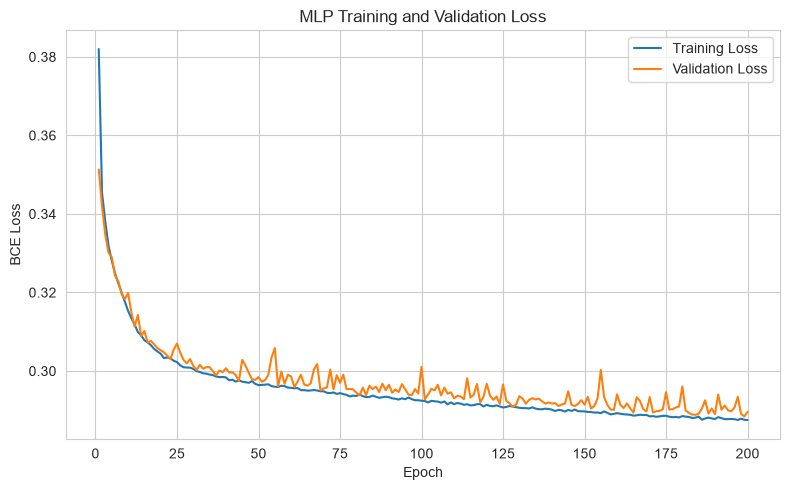

In [17]:
# ============================================================
# STEP 12.1 — MLP training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("MLP Training and Validation Loss")

plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# STEP 13 — Generate multi-label predictions
# ============================================================

from scipy.special import expit

THRESHOLD = 0.50

model.eval()

with torch.no_grad():

    test_logits = model(
        X_test_tensor.to(DEVICE)
    )

    test_probabilities = torch.sigmoid(
        test_logits
    ).cpu().numpy()

# ------------------------------------------------------------
# Convert probabilities to binary labels
# ------------------------------------------------------------

test_predictions = (
    test_probabilities >= THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Convert to DataFrames
# ------------------------------------------------------------

Y_prob = pd.DataFrame(
    test_probabilities,
    columns=TARGET_COLS,
    index=Y_test.index
)

Y_pred = pd.DataFrame(
    test_predictions,
    columns=TARGET_COLS,
    index=Y_test.index
)

print("=" * 70)
print("MLP PREDICTIONS")
print("=" * 70)

print(f"Threshold: {THRESHOLD}")

print("\nFirst 10 predicted probabilities:")

display(
    Y_prob.head(10)
)

print("\nFirst 10 predicted labels:")

display(
    Y_pred.head(10)
)

MLP PREDICTIONS
Threshold: 0.5

First 10 predicted probabilities:


,CPU,Memory,Cache,IO,Lock,ContextSwitch
507494,0.999,0.998,0.421,0.003,0.002,0.260
676843,0.849,0.894,0.115,0.312,0.109,0.172
449653,0.996,0.991,0.360,0.017,0.014,0.249
522672,0.999,0.998,0.319,0.001,0.000,0.283
477877,0.906,0.875,0.237,0.206,0.097,0.234
470979,1.000,1.000,0.775,0.000,0.000,0.131
679721,1.000,1.000,0.643,0.000,0.000,0.284
386352,1.000,1.000,0.006,0.000,0.000,0.241
185164,1.000,0.875,0.000,0.857,0.998,0.000
507951,1.000,0.999,0.327,0.001,0.000,0.308



First 10 predicted labels:


,CPU,Memory,Cache,IO,Lock,ContextSwitch
507494,1,1,0,0,0,0
676843,1,1,0,0,0,0
449653,1,1,0,0,0,0
522672,1,1,0,0,0,0
477877,1,1,0,0,0,0
470979,1,1,1,0,0,0
679721,1,1,1,0,0,0
386352,1,1,0,0,0,0
185164,1,1,0,1,1,0
507951,1,1,0,0,0,0


In [19]:
# ============================================================
# STEP 14 — Evaluate MLP attribution performance
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    hamming_loss
)

print("=" * 70)
print("MLP BOTTLENECK ATTRIBUTION PERFORMANCE")
print("=" * 70)

results = []

for target in TARGET_COLS:

    y_true = Y_test[target].values
    y_pred = Y_pred[target].values
    y_prob = Y_prob[target].values

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    try:

        auc = roc_auc_score(
            y_true,
            y_prob
        )

    except ValueError:

        auc = np.nan

    results.append({
        "target": target,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc
    })

    print("\n" + target)

    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1       : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")


# ============================================================
# Overall multi-label metrics
# ============================================================

print("\n" + "=" * 70)
print("OVERALL MULTI-LABEL PERFORMANCE")
print("=" * 70)

hamming = hamming_loss(
    Y_test,
    Y_pred
)

micro_f1 = f1_score(
    Y_test,
    Y_pred,
    average="micro",
    zero_division=0
)

macro_f1 = f1_score(
    Y_test,
    Y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)

exact_match = np.all(
    Y_test.values == Y_pred.values,
    axis=1
).mean()

print(f"Hamming Loss       : {hamming:.4f}")
print(f"Micro F1           : {micro_f1:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Weighted F1        : {weighted_f1:.4f}")
print(f"Exact Match Ratio  : {exact_match:.4f}")

results_df = pd.DataFrame(results)

display(results_df)

MLP BOTTLENECK ATTRIBUTION PERFORMANCE

CPU
  Accuracy : 0.9374
  Precision: 0.9390
  Recall   : 0.9977
  F1       : 0.9675
  ROC-AUC  : 0.8850

Memory
  Accuracy : 0.9127
  Precision: 0.9177
  Recall   : 0.9919
  F1       : 0.9533
  ROC-AUC  : 0.8707

Cache
  Accuracy : 0.8244
  Precision: 0.7242
  Recall   : 0.1412
  F1       : 0.2363
  ROC-AUC  : 0.7993

IO
  Accuracy : 0.8545
  Precision: 0.6946
  Recall   : 0.2201
  F1       : 0.3343
  ROC-AUC  : 0.8632

Lock
  Accuracy : 0.9045
  Precision: 0.8312
  Recall   : 0.3317
  F1       : 0.4742
  ROC-AUC  : 0.8758

ContextSwitch
  Accuracy : 0.8296
  Precision: 0.7391
  Recall   : 0.0423
  F1       : 0.0800
  ROC-AUC  : 0.7630

OVERALL MULTI-LABEL PERFORMANCE
Hamming Loss       : 0.1228
Micro F1           : 0.8401
Macro F1           : 0.5076
Weighted F1        : 0.7759
Exact Match Ratio  : 0.4018


,target,accuracy,precision,recall,f1,roc_auc
0,CPU,0.937,0.939,0.998,0.967,0.885
1,Memory,0.913,0.918,0.992,0.953,0.871
2,Cache,0.824,0.724,0.141,0.236,0.799
3,IO,0.854,0.695,0.220,0.334,0.863
4,Lock,0.904,0.831,0.332,0.474,0.876
5,ContextSwitch,0.830,0.739,0.042,0.080,0.763


In [20]:
# ============================================================
# STEP 14.1 — Composite bottleneck evaluation
# ============================================================

print("=" * 70)
print("COMPOSITE BOTTLENECK EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Create actual and predicted combinations
# ------------------------------------------------------------

actual_combo = (
    Y_test[TARGET_COLS]
    .astype(int)
    .astype(str)
    .agg(" + ".join, axis=1)
)

predicted_combo = (
    Y_pred[TARGET_COLS]
    .astype(int)
    .astype(str)
    .agg(" + ".join, axis=1)
)

# More readable names
def get_bottleneck_name(row):

    active = [
        target
        for target in TARGET_COLS
        if row[target] == 1
    ]

    return " + ".join(active) if active else "None"


actual_names = Y_test.apply(
    get_bottleneck_name,
    axis=1
)

predicted_names = Y_pred.apply(
    get_bottleneck_name,
    axis=1
)

# ------------------------------------------------------------
# Exact match
# ------------------------------------------------------------

exact_match = (
    actual_names.values ==
    predicted_names.values
)

print(
    f"\nExact Match Ratio: "
    f"{exact_match.mean():.4f}"
)

# ------------------------------------------------------------
# Show actual vs predicted combinations
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "actual": actual_names,
    "predicted": predicted_names
})

print("\nMost common actual combinations:")

display(
    comparison["actual"]
    .value_counts()
    .head(20)
    .rename_axis("combination")
    .reset_index(name="count")
)

print("\nActual vs predicted combinations:")

display(
    comparison
    .value_counts()
    .rename("count")
    .reset_index()
    .head(30)
)

COMPOSITE BOTTLENECK EVALUATION

Exact Match Ratio: 0.4018

Most common actual combinations:


,combination,count
0,CPU + Memory,95705
1,CPU + Memory + Cache,53478
2,CPU + Memory + ContextSwitch,48684
3,CPU + Memory + IO + Lock,23068
4,CPU + Memory + IO,18630
5,CPU,10675
6,Memory,10221
7,CPU + Lock,7076
8,Lock,5953
9,IO,2592



Actual vs predicted combinations:


,actual,predicted,count
0,CPU + Memory,CPU + Memory,90099
1,CPU + Memory + Cache,CPU + Memory,45793
2,CPU + Memory + ContextSwitch,CPU + Memory,45616
3,CPU + Memory + IO,CPU + Memory,15887
4,CPU + Memory + IO + Lock,CPU + Memory,14639
5,Memory,CPU + Memory,9382
6,CPU,CPU + Memory,8649
7,CPU + Memory + Cache,CPU + Memory + Cache,7551
8,CPU + Memory + IO + Lock,CPU + Memory + IO + Lock,5337
9,CPU + Lock,CPU + Memory,3886


In [21]:
# ============================================================
# STEP 15 — Save MLP attribution model artifacts
# ============================================================

import os
import json
import joblib
import torch

ARTIFACT_DIR = "mlp_attribution_artifacts"

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

print("=" * 70)
print("SAVING MLP ATTRIBUTION ARTIFACTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Save PyTorch model
# ------------------------------------------------------------

model_path = os.path.join(
    ARTIFACT_DIR,
    "bottleneck_mlp.pt"
)

torch.save(
    model.state_dict(),
    model_path
)

print(f"Saved model: {model_path}")

# ------------------------------------------------------------
# 2. Save feature list
# ------------------------------------------------------------

feature_path = os.path.join(
    ARTIFACT_DIR,
    "attribution_feature_cols.json"
)

with open(feature_path, "w") as f:

    json.dump(
        ATTR_FEATURES,
        f,
        indent=2
    )

print(f"Saved features: {feature_path}")

# ------------------------------------------------------------
# 3. Save target list
# ------------------------------------------------------------

target_path = os.path.join(
    ARTIFACT_DIR,
    "attribution_target_cols.json"
)

with open(target_path, "w") as f:

    json.dump(
        TARGET_COLS,
        f,
        indent=2
    )

print(f"Saved targets: {target_path}")

# ------------------------------------------------------------
# 4. Save scaler
# ------------------------------------------------------------

scaler_path = os.path.join(
    ARTIFACT_DIR,
    "feature_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print(f"Saved scaler: {scaler_path}")

# ------------------------------------------------------------
# 5. Save configuration
# ------------------------------------------------------------

model_config = {
    "model_type": "PyTorch MLP",
    "input_dim": INPUT_DIM,
    "hidden_layers": [64, 24, 16],
    "output_dim": OUTPUT_DIM,
    "activation": "ReLU",
    "output_activation": "Sigmoid",
    "loss": "BCEWithLogitsLoss",
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "threshold": THRESHOLD,
    "random_state": RANDOM_STATE
}

config_path = os.path.join(
    ARTIFACT_DIR,
    "mlp_config.json"
)

with open(config_path, "w") as f:

    json.dump(
        model_config,
        f,
        indent=2
    )

print(f"Saved config: {config_path}")

# ------------------------------------------------------------
# 6. Save test predictions
# ------------------------------------------------------------

prediction_path = os.path.join(
    ARTIFACT_DIR,
    "test_predictions.csv"
)

Y_pred.to_csv(
    prediction_path,
    index=False
)

print(f"Saved predictions: {prediction_path}")

# ------------------------------------------------------------
# 7. Save test probabilities
# ------------------------------------------------------------

probability_path = os.path.join(
    ARTIFACT_DIR,
    "test_probabilities.csv"
)

Y_prob.to_csv(
    probability_path,
    index=False
)

print(f"Saved probabilities: {probability_path}")

# ------------------------------------------------------------
# 8. Save evaluation results
# ------------------------------------------------------------

results_path = os.path.join(
    ARTIFACT_DIR,
    "mlp_attribution_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(f"Saved results: {results_path}")

print("\n" + "=" * 70)
print("ALL MLP ARTIFACTS SAVED")
print("=" * 70)

SAVING MLP ATTRIBUTION ARTIFACTS
Saved model: mlp_attribution_artifacts\bottleneck_mlp.pt
Saved features: mlp_attribution_artifacts\attribution_feature_cols.json
Saved targets: mlp_attribution_artifacts\attribution_target_cols.json
Saved scaler: mlp_attribution_artifacts\feature_scaler.pkl
Saved config: mlp_attribution_artifacts\mlp_config.json
Saved predictions: mlp_attribution_artifacts\test_predictions.csv
Saved probabilities: mlp_attribution_artifacts\test_probabilities.csv
Saved results: mlp_attribution_artifacts\mlp_attribution_results.csv

ALL MLP ARTIFACTS SAVED
